# 05 - Daily-adaptive DLinear experiment sequence

This notebook follows the evidence from the earlier RevIN, slice-aware, and daily/weekly experiments. ETTh1 showed useful daily structure, weak weekly weights, and strong feature-dependent behavior. We therefore test two small changes separately before allowing them to be combined:

1. **Cross-period daily residual:** reshape 336 hours into 14 days and learn a shared `14 -> H/24` mapping for every hour-of-day and feature. The branch is initialized to zero, so the initial forecast is exactly DLinear.
2. **Rank-1 channel adapters:** retain shared DLinear projections and add zero-initialized, feature-specific rank-1 corrections.
3. **Validation-selected raw/RevIN mask:** select raw or RevIN-DLinear independently for each feature using mean validation MSE across the three development seeds.

The daily and low-rank branches are combined only if both independently beat paired DLinear on mean validation MSE across seeds 2021-2023. One consensus normalization mask and the best candidate are then frozen from 96-hour validation results and compared with paired DLinear at horizons 192, 336, and 720. Test metrics never control model selection.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'pyproject.toml').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.run_daily_adaptation_sequence import (
    per_feature_rows, run_sequence, summary_rows,
)

CONFIG = PROJECT_ROOT / 'configs' / 'daily_adaptation_sequence.yaml'
OUTPUT = PROJECT_ROOT / 'results' / 'dlinear' / 'daily_adaptation_sequence'
CONFIG, OUTPUT

(WindowsPath('C:/Users/guyin/OneDrive/Documents/grad_school/year_1/time_series_analysis/repos/long-horizon-time-series-forecasting/configs/daily_adaptation_sequence.yaml'),
 WindowsPath('C:/Users/guyin/OneDrive/Documents/grad_school/year_1/time_series_analysis/repos/long-horizon-time-series-forecasting/results/dlinear/daily_adaptation_sequence'))

## Run the staged experiment

Every model receives a newly seeded shuffled training loader. Checkpoints are restored from the best validation epoch. The complete configuration, individual-seed metrics, training histories, summary table, and feature table are written under `results/dlinear/daily_adaptation_sequence/`.

In [2]:
results = run_sequence(
    config_path=CONFIG,
    output=OUTPUT,
    device_name='auto',
    reuse_completed_runs=True,  # Set False to retrain every model from scratch.
)
results['selection']

Reused completed paired runs and wrote consensus results to C:\Users\guyin\OneDrive\Documents\grad_school\year_1\time_series_analysis\repos\long-horizon-time-series-forecasting\results\dlinear\daily_adaptation_sequence


{'development_horizon': 96,
 'baseline_mean_validation_MSE': 0.6419225472558312,
 'candidate_mean_validation_MSE': {'CrossPeriodDaily': 0.6468533684087222,
  'LowRankDLinear': 0.6674776374700281,
  'ConsensusRawRevIN': 0.6414175628654871},
 'daily_mean_validation_MSE': 0.6468533684087222,
 'low_rank_mean_validation_MSE': 0.6674776374700281,
 'combine_ran': False,
 'frozen_normalized_features': ['OT'],
 'selected_candidate': 'ConsensusRawRevIN',
 'selected_candidate_beats_baseline': True}

## Aggregate comparison

The table reports mean and sample standard deviation across three seeds. Improvement percentages are paired against DLinear at the same horizon; positive values mean lower error. The paper's reported ETTh1-96 DLinear result is MSE 0.375 and MAE 0.399.

In [3]:
summary = pd.DataFrame(summary_rows(results))
baseline = summary.loc[summary.model.eq('DLinear'), ['horizon', 'test_MSE_mean', 'test_MAE_mean']].rename(
    columns={'test_MSE_mean': 'baseline_MSE', 'test_MAE_mean': 'baseline_MAE'}
)
summary = summary.merge(baseline, on='horizon', how='left')
summary['MSE improvement vs DLinear (%)'] = 100 * (1 - summary.test_MSE_mean / summary.baseline_MSE)
summary['MAE improvement vs DLinear (%)'] = 100 * (1 - summary.test_MAE_mean / summary.baseline_MAE)
display(summary.sort_values(['horizon', 'validation_MSE_mean']).round(6))

,horizon,model,seeds,validation_MSE_mean,validation_MSE_std,test_MSE_mean,test_MSE_std,test_MAE_mean,test_MAE_std,parameters,baseline_MSE,baseline_MAE,MSE improvement vs DLinear (%),MAE improvement vs DLinear (%)
0,96,ConsensusRawRevIN,3,0.641418,0.006620,0.373201,0.005497,0.394751,0.005408,129422,0.381133,0.405212,2.081034,2.581636
2,96,DLinear,3,0.641923,0.006038,0.381133,0.012862,0.405212,0.015507,64704,0.381133,0.405212,0.000000,0.000000
1,96,CrossPeriodDaily,3,0.646853,0.001389,0.373296,0.001520,0.395716,0.002015,64760,0.381133,0.405212,2.056206,2.343418
3,96,LowRankDLinear,3,0.667478,0.000270,0.374527,0.004194,0.397293,0.004486,70752,0.381133,0.405212,1.733178,1.954318
4,96,RevIN-DLinear,3,0.673488,0.001324,0.371109,0.001313,0.392090,0.000928,64718,0.381133,0.405212,2.629965,3.238306
5,192,ConsensusRawRevIN,3,0.859673,0.004662,0.406044,0.005892,0.414709,0.005115,258830,0.414595,0.424826,2.062614,2.381456
6,192,DLinear,3,0.860355,0.004365,0.414595,0.009953,0.424826,0.010200,129408,0.414595,0.424826,0.000000,0.000000
7,192,RevIN-DLinear,3,0.920179,0.001384,0.405133,0.001086,0.412399,0.000796,129422,0.414595,0.424826,2.282408,2.925201
8,336,ConsensusRawRevIN,3,1.042007,0.008117,0.451056,0.037086,0.446559,0.029432,452942,0.489374,0.480688,7.829900,7.100122
9,336,DLinear,3,1.044811,0.005377,0.489374,0.080371,0.480688,0.062143,226464,0.489374,0.480688,0.000000,0.000000


## Development-horizon decision

Only validation MSE is used to decide whether the two architectural ablations may be combined and which candidate continues to the longer horizons.

In [4]:
development = summary.loc[summary.horizon.eq(96)].copy()
display(development.sort_values('validation_MSE_mean').round(6))
print('Combination ran:', results['selection']['combine_ran'])
print('Frozen normalized features:', results['selection']['frozen_normalized_features'])
print('Frozen candidate:', results['selection']['selected_candidate'])
print('Candidate beat DLinear on validation:', results['selection']['selected_candidate_beats_baseline'])

,horizon,model,seeds,validation_MSE_mean,validation_MSE_std,test_MSE_mean,test_MSE_std,test_MAE_mean,test_MAE_std,parameters,baseline_MSE,baseline_MAE,MSE improvement vs DLinear (%),MAE improvement vs DLinear (%)
0,96,ConsensusRawRevIN,3,0.641418,0.006620,0.373201,0.005497,0.394751,0.005408,129422,0.381133,0.405212,2.081034,2.581636
2,96,DLinear,3,0.641923,0.006038,0.381133,0.012862,0.405212,0.015507,64704,0.381133,0.405212,0.000000,0.000000
1,96,CrossPeriodDaily,3,0.646853,0.001389,0.373296,0.001520,0.395716,0.002015,64760,0.381133,0.405212,2.056206,2.343418
3,96,LowRankDLinear,3,0.667478,0.000270,0.374527,0.004194,0.397293,0.004486,70752,0.381133,0.405212,1.733178,1.954318
4,96,RevIN-DLinear,3,0.673488,0.001324,0.371109,0.001313,0.392090,0.000928,64718,0.381133,0.405212,2.629965,3.238306


Combination ran: False
Frozen normalized features: ['OT']
Frozen candidate: ConsensusRawRevIN
Candidate beat DLinear on validation: True


## Per-feature 96-hour results

Feature errors are averaged across the same three seeds. This makes it possible to see whether a small aggregate change is broad or driven by one variable.

In [5]:
features = pd.DataFrame(per_feature_rows(results, horizon=96))
selected_name = results['selection']['selected_candidate']
feature_comparison = features.loc[features.model.isin(['DLinear', selected_name])].pivot(
    index='feature', columns='model', values=['test_MSE_mean', 'test_MAE_mean']
)
feature_comparison[('MSE improvement (%)', selected_name)] = 100 * (
    1 - feature_comparison[('test_MSE_mean', selected_name)] / feature_comparison[('test_MSE_mean', 'DLinear')]
)
feature_comparison[('MAE improvement (%)', selected_name)] = 100 * (
    1 - feature_comparison[('test_MAE_mean', selected_name)] / feature_comparison[('test_MAE_mean', 'DLinear')]
)
display(feature_comparison.round(6))

test_MSE_mean               test_MAE_mean            \
model   ConsensusRawRevIN   DLinear ConsensusRawRevIN   DLinear   
feature                                                           
HUFL             0.754462  0.754462          0.588070  0.588070   
HULL             0.213210  0.213210          0.344447  0.344447   
LUFL             0.516136  0.516136          0.500107  0.500107   
LULL             0.123999  0.123999          0.272232  0.272232   
MUFL             0.779031  0.779031          0.584323  0.584323   
MULL             0.172671  0.172671          0.299405  0.299405   
OT               0.052898  0.108419          0.174670  0.247898   

        MSE improvement (%) MAE improvement (%)  
model     ConsensusRawRevIN   ConsensusRawRevIN  
feature                                          
HUFL               0.000000            0.000000  
HULL               0.000000            0.000000  
LUFL               0.000000            0.000000  
LULL               0.000000            0.000000  
MUFL               0.000000            0.000000  
MULL               0.000000            0.000000  
OT                51.209406           29.539457

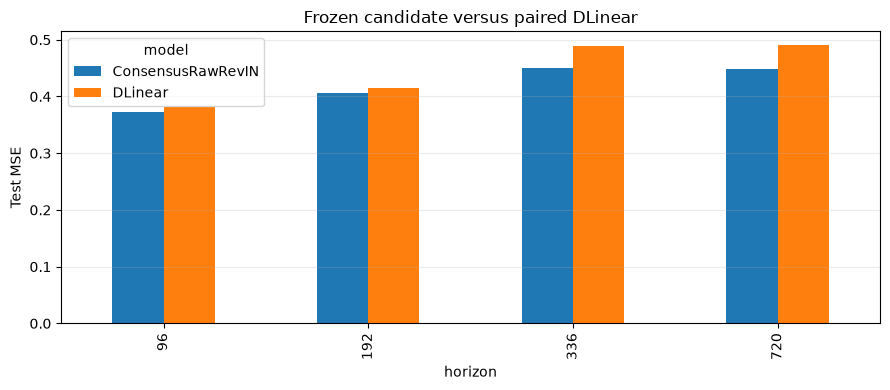

In [6]:
plot_data = summary.loc[summary.model.isin(['DLinear', selected_name])].copy()
ax = plot_data.pivot(index='horizon', columns='model', values='test_MSE_mean').plot.bar(
    figsize=(9, 4), ylabel='Test MSE', title='Frozen candidate versus paired DLinear'
)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## Comparison with the original reported metrics

The repeated-seed comparison above is the fairest test of the method. For continuity with the original project, this table also includes the paper-reported DLinear result and the repository's earlier single-seed reconstruction. The candidate's seed-2021 row is shown separately so it can be compared under the same seed.

In [7]:
import json

original_path = PROJECT_ROOT / 'results' / 'dlinear' / 'reconstruction' / 'etth1' / 'horizon_096' / 'seed_2021' / 'metrics.json'
original = json.loads(original_path.read_text())['DLinear reconstruction']
consensus_seed_2021 = results['runs']['horizon_096']['2021']['ConsensusRawRevIN']['test']
consensus_mean = summary.loc[(summary.horizon == 96) & (summary.model == selected_name)].iloc[0]
original_comparison = pd.DataFrame([
    {'Result': 'Paper-reported DLinear', 'Seeds': '-', 'MSE': 0.375, 'MAE': 0.399},
    {'Result': 'Original repository reconstruction', 'Seeds': '2021', 'MSE': original['MSE'], 'MAE': original['MAE']},
    {'Result': 'Consensus raw/RevIN', 'Seeds': '2021', 'MSE': consensus_seed_2021['MSE'], 'MAE': consensus_seed_2021['MAE']},
    {'Result': 'Paired DLinear mean', 'Seeds': '2021-2023', 'MSE': summary.loc[(summary.horizon == 96) & (summary.model == 'DLinear'), 'test_MSE_mean'].iloc[0], 'MAE': summary.loc[(summary.horizon == 96) & (summary.model == 'DLinear'), 'test_MAE_mean'].iloc[0]},
    {'Result': 'Consensus raw/RevIN mean', 'Seeds': '2021-2023', 'MSE': consensus_mean.test_MSE_mean, 'MAE': consensus_mean.test_MAE_mean},
])
display(original_comparison.round(6))

,Result,Seeds,MSE,MAE
0,Paper-reported DLinear,-,0.375000,0.399000
1,Original repository reconstruction,2021,0.370509,0.392145
2,Consensus raw/RevIN,2021,0.368971,0.390531
3,Paired DLinear mean,2021-2023,0.381133,0.405212
4,Consensus raw/RevIN mean,2021-2023,0.373201,0.394751


## Reproducible conclusion

The cell below generates the conclusion directly from stored measurements so the interpretation stays synchronized with reruns.

In [8]:
selected_rows = summary.loc[summary.model.eq(selected_name)].sort_values('horizon')
for _, row in selected_rows.iterrows():
    print(
        f"H={int(row['horizon'])}: {selected_name} MSE={row['test_MSE_mean']:.6f} "
        f"({row['MSE improvement vs DLinear (%)']:+.2f}% vs DLinear), "
        f"MAE={row['test_MAE_mean']:.6f}."
    )
print('A method is claimed as improved only when validation and repeated-seed test evidence agree.')

H=96: ConsensusRawRevIN MSE=0.373201 (+2.08% vs DLinear), MAE=0.394751.
H=192: ConsensusRawRevIN MSE=0.406044 (+2.06% vs DLinear), MAE=0.414709.
H=336: ConsensusRawRevIN MSE=0.451056 (+7.83% vs DLinear), MAE=0.446559.
H=720: ConsensusRawRevIN MSE=0.448748 (+8.48% vs DLinear), MAE=0.459416.
A method is claimed as improved only when validation and repeated-seed test evidence agree.
